<a href="https://colab.research.google.com/github/Siriri0712/Immersive-Project/blob/main/Heatmap%20and%20Graph%20Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

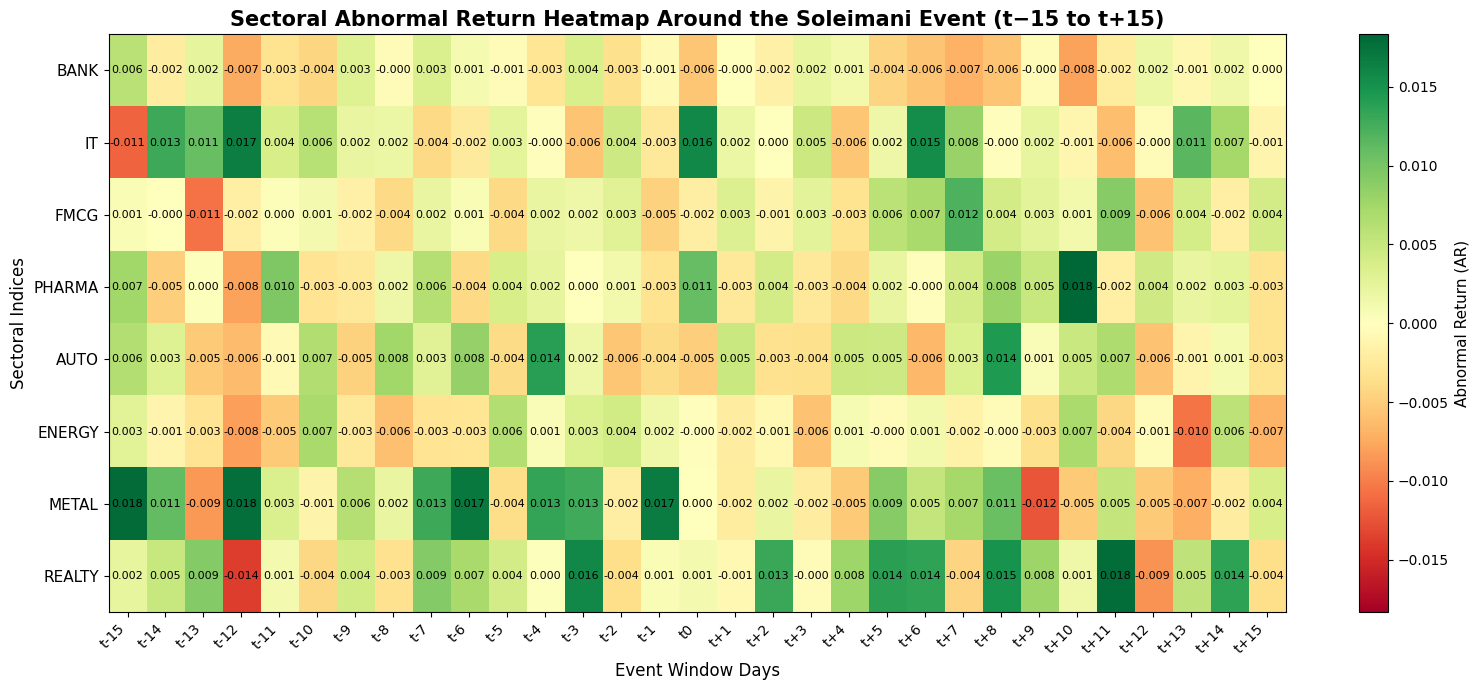

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# -----------------------------
# 1) Load your data
# -----------------------------
# If you exported from Excel, use either:
df = pd.read_csv("/content/Heatmap Data - Sheet1.csv")
# OR if using Excel directly:
# df = pd.read_excel("/content/Event_Study_Workbook_Completed.xlsx", sheet_name="Python_Heatmap_Data")

# df = pd.read_excel("/content/Event_Study_Workbook_Completed.xlsx", sheet_name="Python_Heatmap_Data")

# -----------------------------
# 2) Clean column names
# -----------------------------
df.columns = [c.strip().upper() for c in df.columns]

# Expected columns:
# LABEL, BANK_AR, IT_AR, FMCG_AR, PHARMA_AR, AUTO_AR, ENERGY_AR, METAL_AR, REALTY_AR

sector_cols = ["BANK_AR", "IT_AR", "FMCG_AR", "PHARMA_AR", "AUTO_AR", "ENERGY_AR", "METAL_AR", "REALTY_AR"]

# Keep only what we need
df = df[["LABEL"] + sector_cols].copy()

# -----------------------------
# 3) Arrange data for heatmap
# -----------------------------
# Put sectors on y-axis, event days on x-axis
heatmap_data = df[sector_cols].T.values

# Create nice x-axis labels
x_labels = df["LABEL"].tolist()
y_labels = [col.replace("_AR", "") for col in sector_cols] # Remove _AR for cleaner y-axis labels

# -----------------------------
# 4) Plot
# -----------------------------
plt.figure(figsize=(16, 7))

# Center the color scale at 0 so positive and negative ARs stand out clearly
vmax = np.nanmax(np.abs(heatmap_data))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

im = plt.imshow(
    heatmap_data,
    aspect="auto",
    cmap="RdYlGn",
    norm=norm
)

# Axis labels
plt.xticks(ticks=np.arange(len(x_labels)), labels=x_labels, rotation=45, ha="right", fontsize=10)
plt.yticks(ticks=np.arange(len(y_labels)), labels=y_labels, fontsize=11)

# Vertical line for event day t0
t0_index = x_labels.index("T0") if "T0" in x_labels else None # Changed from 't0' to 'T0'
if t0_index is not None:
    plt.axvline(x=t0_index, color="black", linewidth=2, linestyle="--")
    plt.text(t0_index, -0.75, "EVENT DAY", ha="center", va="bottom", fontsize=10, fontweight="bold")

# Add values inside each cell
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val = heatmap_data[i, j]
        plt.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=8, color="black")

# Titles
plt.title("Sectoral Abnormal Return Heatmap Around the Soleimani Event (t−15 to t+15)", fontsize=15, fontweight="bold")
plt.xlabel("Event Window Days", fontsize=12)
plt.ylabel("Sectoral Indices", fontsize=12)

# Colorbar
cbar = plt.colorbar(im)
cbar.set_label("Abnormal Return (AR)", fontsize=11)

plt.tight_layout()
plt.show()

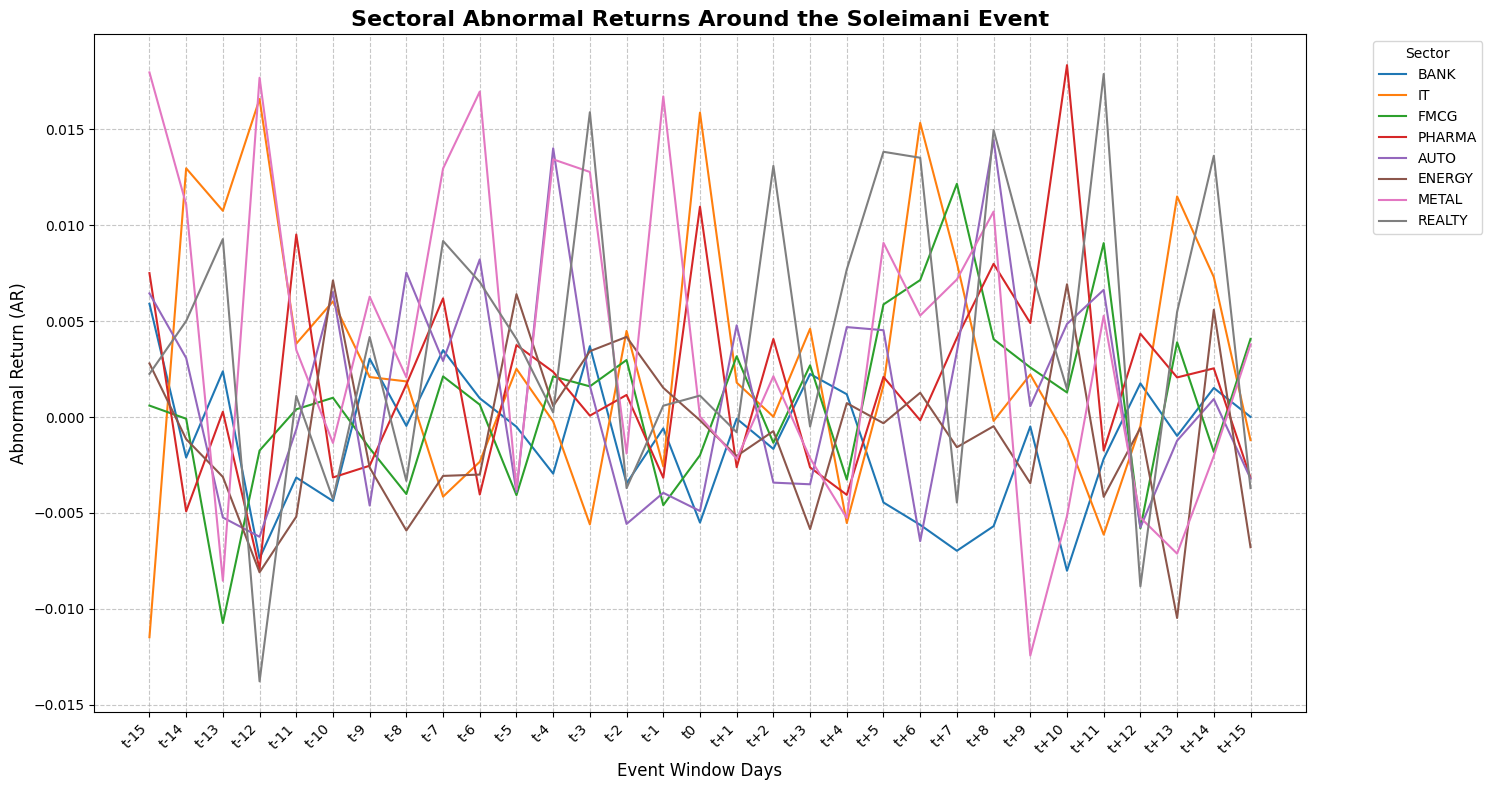

In [3]:
plt.figure(figsize=(15, 8))

# Plot each sector's abnormal returns as a line
for sector in sector_cols:
    plt.plot(df["LABEL"], df[sector], label=sector.replace("_AR", ""))

# Vertical line for event day T0
t0_index = x_labels.index("T0") if "T0" in x_labels else None
if t0_index is not None:
    plt.axvline(x=x_labels[t0_index], color='black', linestyle='--', linewidth=2, label='Event Day T0')

# Titles and labels
plt.title("Sectoral Abnormal Returns Around the Soleimani Event", fontsize=16, fontweight='bold')
plt.xlabel("Event Window Days", fontsize=12)
plt.ylabel("Abnormal Return (AR)", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title="Sector", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()